# Giải trí — công viên, sân vận động, khu vui chơi

Nối tiếp `eda_thuongmai.ipynb`. Đầu vào: `poi_extended_7tinh_con_lai_sau_thuongmai.parquet`.

Lớp này có hình thái **cực đoan nhất chuỗi cho tới giờ**, và nó lật ngược mọi giả định:

| | lớp nhà ở | lớp lưu trú | lớp thương mại | **lớp giải trí** |
|---|---|---|---|---|
| polygon | 94% | 26% | 47% | **94%** |
| có tên | ~60% | 75% | 77% | **13%** |
| `n_tags` trung vị | 3 | 6 | 4 | **1** |
| quy mô nằm ở đâu | diện tích | tên tiếng Việt | từ vựng `shop=*` | **không ở đâu cả** |

94% polygon nhưng **87% VÔ DANH**, và trung vị **một tag duy nhất**. `leisure=*` không có
thang bậc như `shop=*`: một công viên trung tâm 20 ha và một bồn cỏ 70 m² đều có thể là
`leisure=park`; `landuse=grass` (6.237 dòng) thì không phải cơ sở gì cả.

Nên câu hỏi của lớp này không phải "to hay nhỏ" mà là **"đây có phải một ĐIỂM ĐẾN không,
hay chỉ là MẶT PHỦ / một THÀNH PHẦN của khuôn viên khác"**. Sân bóng trong sân trường là
thật, nhưng nó không phải nơi ai lái xe tới rồi cắm sạc — và đếm nó là đếm đôi với lớp
trường học sắp tới.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"
LOP = "giaitri"
LOP_TRUOC = "thuongmai"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP_TRUOC}.parquet").to_pandas()


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


poi["tags_dict"] = poi["tags"].map(parse_tags)
td = poi["tags_dict"]


def strip_accents(s: str) -> str:
    """Hạ chữ + bỏ dấu tiếng Việt (đ/Đ xử lý riêng vì NFD không tách được)."""
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    return td.map(lambda t, k=key: str(t[k]).lower() if k in t else None)


for k in [
    "leisure",
    "landuse",
    "amenity",
    "sport",
    "building",
    "tourism",
    "natural",
    "shop",
    "office",
    "historic",
    "man_made",
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "waterway",
    "power",
    "barrier",
    "craft",
    "healthcare",
    "military",
    "place",
]:
    poi[k] = tag(k)
poi["brand"] = td.map(lambda t: t.get("brand"))
poi["operator"] = td.map(lambda t: t.get("operator"))

alt_names = td.map(
    lambda t: " ".join(
        v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v
    )
)
poi["name_norm"] = (
    poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)
).str.strip()
# BẪY kế thừa từ lớp thương mại: `\b` cạnh chữ CÒN DẤU trượt im lặng trên cột dtype `str`
# (pandas dùng RE2, ở đó `\b` chỉ hiểu ASCII). Lớp này chỉ dùng `name_norm` — đã bỏ dấu nên
# thuần ASCII, `\b` an toàn. Giữ `name_dau` ở dtype object phòng khi cần.
poi["name_dau"] = poi["name"].fillna("").astype(object).str.lower()
name_norm = poi["name_norm"]

print(
    f"bộ vào: {len(poi):,} dòng | polygon {poi['is_area'].mean():.0%} | có tên {poi['name'].notna().mean():.0%}"
)

bộ vào: 176,615 dòng | polygon 40% | có tên 47%


## Chân dung hình thái — và vì sao mọi trục trước đều chết ở đây

In [2]:
_ung_vien = poi["leisure"].notna() | poi["landuse"].isin(
    ["grass", "recreation_ground", "village_green"]
)
_uv = poi[_ung_vien]
print(
    f"ứng viên thô: {len(_uv):,} | polygon {_uv['is_area'].mean():.0%}"
    f" | có tên {_uv['name'].notna().mean():.0%} | n_tags trung vị {_uv['n_tags'].median():.0f}"
    f" | có brand {_uv['brand'].notna().mean():.1%}"
)

print("\n── 1. `leisure=*` có phải thang bậc như `shop=*` không? ──")
bang = _uv.groupby("leisure").agg(
    n=("name", "size"),
    co_ten=("name", lambda s: s.notna().mean()),
    dt_trung_vi=("area_m2", lambda s: s[s > 0].median()),
)
print(
    bang[bang["n"] >= 40]
    .sort_values("n", ascending=False)
    .assign(
        co_ten=lambda d: (d.co_ten * 100).round(0), dt_trung_vi=lambda d: d.dt_trung_vi.round(0)
    )
    .to_string()
)
print(
    "→ KHÔNG. `pitch` 721 m² và `park` 3.057 m² không cách nhau một bậc như `mall` với"
    " `convenience`; và `golf_course` 906.000 m² thì lệch ba bậc so với mọi thứ còn lại."
)

print("\n── 2. ĐỘ PHỦ TÊN theo diện tích: điểm nhấc nằm ở đâu? ──")
_a = _uv[_uv["is_area"] & _uv["area_m2"].gt(0)].copy()
_a["band"] = pd.cut(
    _a["area_m2"],
    [0, 200, 500, 1_000, 2_000, 5_000, 20_000, np.inf],
    labels=["<200", "200–500", "500–1k", "1k–2k", "2k–5k", "5k–20k", ">20k"],
)
bang2 = _a.groupby("band", observed=True).agg(
    n=("name", "size"), co_ten=("name", lambda s: s.notna().mean())
)
bang2["co_ten %"] = (bang2["co_ten"] * 100).round(1)
print(bang2[["n", "co_ten %"]].to_string())
print("→ đơn điệu tăng 2,8% → 47,6%, và NHẤC GẤP ĐÔI ở mốc 1.000 m² (5,5% → 10,8%).")
print(
    "  Người map chỉ đặt tên cho thứ mình coi là MỘT NƠI. Độ phủ tên vì thế là thước đo"
    " gián tiếp của 'đây có phải điểm đến không' — thước duy nhất lớp này có."
)

print("\n── 3. các họ tag ứng viên ──")
for k in ["leisure", "landuse", "sport", "amenity"]:
    v = poi[k].value_counts()
    print(f"  {k:9s} {v.sum():6,} → {v.head(9).to_dict()}")

ứng viên thô: 16,445 | polygon 94% | có tên 13% | n_tags trung vị 1 | có brand 0.1%

── 1. `leisure=*` có phải thang bậc như `shop=*` không? ──
                    n  co_ten  dt_trung_vi
leisure                                   
pitch            4343    11.0        721.0
park             2271    31.0       3059.0
swimming_pool     877    13.0        298.0
garden            717     8.0        474.0
playground        391    14.0        413.0
sports_centre     312    73.0       6691.0
fitness_station   204     4.0        259.0
fitness_centre    193    75.0        568.0
stadium           127    67.0       8255.0
track             116     1.0       3653.0
picnic_table      110     0.0          NaN
sports_hall        81    58.0       1684.0
golf_course        51    67.0     777701.0
→ KHÔNG. `pitch` 721 m² và `park` 3.057 m² không cách nhau một bậc như `mall` với `convenience`; và `golf_course` 906.000 m² thì lệch ba bậc so với mọi thứ còn lại.

── 2. ĐỘ PHỦ TÊN theo diện tích: điểm nhấc nằ

### Chọn trục

Ba trục của lớp này, không trục nào bê được từ ba lớp trước:

1. **VAI TRÒ KHÔNG GIAN — thành phần hay chỉnh thể.** Trục *quan trọng nhất*, và là lần đầu
   trong chuỗi quan hệ bao-chứa được dùng để **PHÂN LOẠI** chứ không chỉ để chống đếm đôi.
   Một `leisure=pitch` nằm trong khuôn viên trường là sân của trường, không phải điểm đến.
2. **ĐỘ PHỦ TÊN × DIỆN TÍCH.** Với 87% vô danh, việc *có tên* tự nó là bằng chứng: người
   map đặt tên cho thứ họ coi là một nơi. Đo được: 2,8% ở dải < 200 m² lên 47,6% ở > 2 ha.
3. **`sport=*` — từ vựng chức năng.** Phủ ~27% nhóm thể thao và nói rõ loại hình
   (bóng đá / bơi / tennis), thứ mà `leisure=pitch` không nói.

**Trục bị loại có lý do:** `brand` — phủ 0,3%, chết hẳn (lớp thương mại 16,8%). `shop=*`
không tồn tại ở đây. "Hạng mã hoá trong tên" của lớp lưu trú vô nghĩa khi 87% không có tên.

**Ranh giới lớp, quyết một lần tại đây:** `amenity=cinema` (100) · `theatre` (81) ·
`tourism=museum|artwork|attraction` · `historic=*` **KHÔNG thuộc lớp này** — đề bài xếp
"rạp phim, bảo tàng" vào lớp THAM QUAN, chạy ngay sau. Chúng không được tuyển ở bước 1 và
vẫn còn nguyên trong bộ còn lại. `amenity=nightclub` (74) là giải trí đêm, thuộc lớp ăn
uống — ngoài phạm vi MVP.

## Bước 1 — filter MỎNG, ưu tiên recall

In [3]:
# --- A. tag giải trí/thể thao ---
GT_TAG = (
    poi["leisure"].notna()
    | poi["tourism"].isin(["theme_park", "zoo", "aquarium", "water_park"])
    | poi["building"].isin(["stadium", "sports_hall", "sports_centre", "grandstand", "pavilion"])
)
# --- B. đất công cộng / mặt phủ: tuyển để ĐO rồi mới cắt, không bỏ ngoài từ đầu ---
GT_DAT = poi["landuse"].isin(["recreation_ground", "village_green", "grass", "winter_sports"])
# --- C. tên ---
# TỪ VỰNG khai bằng BẢNG, không bằng một chuỗi nối. Mỗi mục có HAI vai, và chúng KHÁC nhau:
#
#   vai 1 — TUYỂN (bước 1, recall):    token khớp ⇒ mời vào lớp. Mọi mục đều có vai này.
#   vai 2 — BẰNG CHỨNG (bước 3, precision): token khớp + đủ lớn ⇒ được MIỄN các luật xoá.
#           Chỉ mục nào ghi rõ `BANG_CHUNG` mới có. **Mặc định là KHÔNG.**
#
# Vì sao mặc định phải là KHÔNG: bản trước viết `GT_RX_DIEM_DEN = GT_RX.replace(...)` — trừ
# tay đúng hai token. Nghĩa là mọi từ THÊM VÀO SAU NÀY tự động có quyền miễn tội mà không ai
# bấm nút. Ở scope toàn quốc, ai đó thêm `\bgarden\b`/`\bsquare\b`/`\bcenter\b` để bắt tên
# tiếng Anh là lỗ hổng "to + có tên thì bất khả xâm phạm" mở lại ngay, im lặng.
# Bảng này bắt người thêm từ phải TRẢ LỜI câu hỏi cột 2 thì mới thêm được.
#
# Neo biên mọi token ngắn: `svd` là viết tắt SVĐ; `\bcv\b` KHÔNG dùng (khớp "CV" của hồ sơ
# xin việc và tên riêng). "san " trần khớp "Sản", "Sàn" nên phải đi kèm danh từ thể thao.
BANG_CHUNG = True  # đọc tại chỗ dùng: ("san van dong", BANG_CHUNG)

GT_TU_VUNG = [
    # ── công viên / vườn hoa ──
    ("cong vien", BANG_CHUNG),
    (r"\bcvien\b", BANG_CHUNG),
    ("vuon hoa", BANG_CHUNG),
    ("vuon dao", BANG_CHUNG),
    ("thao cam vien", BANG_CHUNG),
    ("cong vien nuoc", BANG_CHUNG),
    ("water ?park", BANG_CHUNG),
    ("cong vien cay xanh", BANG_CHUNG),
    ("vuon uom", BANG_CHUNG),
    ("quang truong", BANG_CHUNG),
    # ── sân bãi thể thao ──
    ("san van dong", BANG_CHUNG),
    (r"\bsvd\b", BANG_CHUNG),
    (r"\bstadium\b", BANG_CHUNG),
    ("san the thao", BANG_CHUNG),
    ("san bong", BANG_CHUNG),
    ("san tennis", BANG_CHUNG),
    ("san cau long", BANG_CHUNG),
    ("san golf", BANG_CHUNG),
    (r"\bgolf\b", BANG_CHUNG),
    ("nha thi dau", BANG_CHUNG),
    # [VÁ SCOPE=vn 2026-08-09] cổng recall 2 ĐỎ đúng 1 dòng: "Nhà thể thao đa năng"
    # (way:968202817, tags chỉ có building=university, 2.246 m²) — từ vựng thiếu đúng
    # token này. Toàn quốc chỉ 3 dòng khớp, cả 3 là nhà thể thao thật ("… UEL" đã vào
    # bằng leisure=sports_centre; "… Khu phố 22" amenity=community_centre ∈ AMENITY_GT_OK).
    # Cùng họ "nhà thi đấu"/"cung thể thao" nên cùng vai BANG_CHUNG.
    ("nha the thao", BANG_CHUNG),
    (r"\bntd\b", BANG_CHUNG),
    ("be boi", BANG_CHUNG),
    ("ho boi", BANG_CHUNG),
    (r"\bbe ?boi\b", BANG_CHUNG),
    ("san dua", BANG_CHUNG),
    ("truong dua", BANG_CHUNG),
    ("karting", BANG_CHUNG),
    ("go-?kart", BANG_CHUNG),
    ("dua xe", BANG_CHUNG),
    # ── vui chơi ──
    ("khu vui choi", BANG_CHUNG),
    ("khu giai tri", BANG_CHUNG),
    ("cong vien giai tri", BANG_CHUNG),
    ("theme ?park", BANG_CHUNG),
    (r"\bsan choi\b", BANG_CHUNG),
    ("san choi tre em", BANG_CHUNG),
    # ── CƠ SỞ văn hoá–thể thao cấp xã/phường: không mang một tag `leisure` nào, chỉ có tên.
    #    Nhóm này do ĐẦU DÒ CỨNG của cổng recall 2 phát hiện ở vòng chạy trước. ──
    ("trung tam the thao", BANG_CHUNG),
    ("khu the thao", BANG_CHUNG),
    ("nha van hoa the thao", BANG_CHUNG),
    ("trung tam (?:the duc )?the thao", BANG_CHUNG),
    # `[^|]` chứ không `.`: chặn khoảng đệm nuốt qua ranh giới alternation khi nối bảng lại.
    ("trung tam van hoa[^|]{0,25}the thao", BANG_CHUNG),
    ("cung the thao", BANG_CHUNG),
    ("khu lien hop the thao", BANG_CHUNG),
    # "CLB Thể Dục Thể Thao Thôn An Trai" — giữa "clb" và "the thao" còn chen "the duc".
    ("cau lac bo[^|]{0,12}the thao", BANG_CHUNG),
    (r"\bclb\b[^|]{0,14}the thao", BANG_CHUNG),
    # `tdtt` là viết tắt phổ biến nhất của "thể dục thể thao" trên biển hiệu VN.
    (r"\btdtt\b", BANG_CHUNG),
    ("trung tam tdtt", BANG_CHUNG),

    # ══ CHỈ TUYỂN, KHÔNG làm bằng chứng ══════════════════════════════════════════════
    # `name_norm` gộp `name:en`/`alt_name`/`old_name` (7,3% bộ vào có trường này), nên một
    # danh từ chung tiếng Anh mở cửa rộng hơn nó trông rất nhiều.
    r"\bpark\b",  # "Car Park", "Industrial Park", "Sky Park", "Hi-Tech Park"
    "san tap",  # "Sân tập lái" — trường dạy lái xe
]


def _tach(muc):
    """Mục viết trần ⇒ chỉ tuyển. Chỉ tuple `(token, BANG_CHUNG)` mới có quyền miễn tội."""
    return muc if isinstance(muc, tuple) else (muc, False)


_tv = [_tach(m) for m in GT_TU_VUNG]
_dup = {t for t, _ in _tv if [x for x, _ in _tv].count(t) > 1}
assert not _dup, f"token trùng trong GT_TU_VUNG: {_dup}"
for _t, _ in _tv:
    re.compile(_t)  # nổ ngay tại dòng khai, không nổ ở giữa pipeline

GT_RX = "|".join(t for t, _ in _tv)
GT_RX_DIEM_DEN = "|".join(t for t, bc in _tv if bc)
_chi_tuyen = [t for t, bc in _tv if not bc]
assert _chi_tuyen, "bảng không còn mục CHỈ TUYỂN nào — mặc định an toàn đã bị vô hiệu"
print(
    f"từ vựng tên: {len(_tv)} token | {len(_tv) - len(_chi_tuyen)} làm bằng chứng điểm đến"
    f" | {len(_chi_tuyen)} CHỈ tuyển: {_chi_tuyen}"
)

# CƠ QUAN QUẢN LÝ nhà nước về thể thao ("Sở Văn hoá và Thể thao") KHÔNG phải cơ sở thể thao.
# Chặn ngay ở nhánh tên thay vì để bước 3 dọn — đó là lớp HÀNH CHÍNH, và chặn ở đây thì
# `drop_reason` của lớp kia không bị nhiễu.
# Danh sách HẸP và neo đầu chuỗi. Đã trả giá một vòng: tiền tố `phong ` trần chặn nhầm
# "Phòng Tập California Wow Yoga & Fitness" — "phòng" vừa là cơ quan vừa là phòng tập.
CO_QUAN_RX = (
    r"^(?:so|cuc|chi cuc|tong cuc|vu|ban quan ly|ban chi dao|uy ban)\s"
    r"|\bso van hoa|\bphong van hoa (?:va|thong tin)|\bso van hoa the thao"
)
GT_NAME = name_norm.str.contains(GT_RX, regex=True, na=False) & ~name_norm.str.contains(
    CO_QUAN_RX, regex=True, na=False
)
# --- D. `sport=*` mà không có `leisure` — sân khai bằng môn thể thao ---
GT_SPORT = poi["sport"].notna() & poi["leisure"].isna()
# --- E. tag vòng đời ---
GT_VONG_DOI = td.map(
    lambda t: any(":" in k and k.split(":")[-1] in {"leisure", "sport"} for k, v in t.items())
)

poi["is_gt"] = GT_TAG | GT_DAT | GT_NAME | GT_SPORT | GT_VONG_DOI
# Dòng CHỈ vào bằng nhánh TÊN — không mang một tag giải trí nào, cả lớp đứng trên đúng
# một chuỗi ký tự. Đây là nhánh mỏng nhất và bước 3 phải có luật riêng cho nó
# (`name_norm` gộp cả `name:en`/`alt_name`/địa chỉ, nên `\bpark\b` kéo vào cả KCN).
poi["gt_chi_ten"] = GT_NAME & ~(GT_TAG | GT_DAT | GT_SPORT | GT_VONG_DOI)

BR = {
    "A tag giải trí": GT_TAG,
    "B đất công cộng": GT_DAT,
    "C tên": GT_NAME,
    "D sport không leisure": GT_SPORT,
    "E vòng đời": GT_VONG_DOI,
}
for ten, m in BR.items():
    print(f"  {ten:24s} {m.sum():6,}")
print(f"  {'HỢP':24s} {poi['is_gt'].sum():6,} / {len(poi):,} ({poi['is_gt'].mean():.2%})")
print("\nđóng góp RIÊNG của từng nhánh:")
for ten, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != ten])
    chi_no = m & ~khac
    print(f"  {ten:24s} {chi_no.sum():5,}  {poi.loc[chi_no, 'name'].dropna().head(3).tolist()}")

từ vựng tên: 49 token | 47 làm bằng chứng điểm đến | 2 CHỈ tuyển: ['\\bpark\\b', 'san tap']
  A tag giải trí           10,170
  B đất công cộng           6,456
  C tên                     2,015
  D sport không leisure       106
  E vòng đời                    5
  HỢP                      17,306 / 176,615 (9.80%)

đóng góp RIÊNG của từng nhánh:
  A tag giải trí           8,775  ['Phòng Tập California Wow Yoga & Fitness', 'Billiards 124', 'Phòng Tập GetFit Gym']
  B đất công cộng          6,409  ['Nhà Văn hóa Thanh niên', 'Vòng xoay Paradise', 'sân']
  C tên                      608  ['Công viên Thống Nhất - Đối diện 326 Lê Duẩn', '73 Văn Cao - Đối diện Cung thể thao Quần Ngựa', '3 Thái Hà - Bể bơi Thái Hà']
  D sport không leisure       77  ['Cat Ba Local', 'Liên Phong Training Center', 'CaDo Billiards Clus']
  E vòng đời                   1  []


### Cổng recall 1 — phủ tag chắc chắn (cổng "vòng tròn")

In [4]:
CHECKS = {
    "leisure=park": poi["leisure"].eq("park"),
    "leisure=stadium": poi["leisure"].eq("stadium"),
    "leisure=pitch": poi["leisure"].eq("pitch"),
    "leisure=sports_centre": poi["leisure"].eq("sports_centre"),
    "leisure=golf_course": poi["leisure"].eq("golf_course"),
    "leisure=water_park": poi["leisure"].eq("water_park"),
    "leisure=playground": poi["leisure"].eq("playground"),
    "landuse=recreation_ground": poi["landuse"].eq("recreation_ground"),
    "landuse=grass": poi["landuse"].eq("grass"),
    "có sport=*": poi["sport"].notna(),
    # trừ CƠ QUAN QUẢN LÝ: "Ban quản lý công viên…" là một phòng ban, không phải công viên.
    # Cổng phải phản ánh đúng luật tuyển, kể cả phần luật CỐ Ý loại — nếu không nó đo sai.
    "tên 'công viên' (trừ cơ quan)": name_norm.str.contains(r"cong vien", na=False)
    & ~name_norm.str.contains(CO_QUAN_RX, regex=True, na=False),
    "tên 'sân vận động|SVĐ'": name_norm.str.contains(r"san van dong|\bsvd\b", na=False),
    "tên 'khu vui chơi'": name_norm.str.contains(r"khu vui choi", na=False),
    "tên 'nhà thi đấu'": name_norm.str.contains(r"nha thi dau", na=False),
}
mat = 0
for ten, m in CHECKS.items():
    thieu = int((m & ~poi["is_gt"]).sum())
    mat += thieu
    print(f"  {ten:28s} giữ {(m & poi['is_gt']).sum():>6,}/{m.sum():<6,}  mất {thieu}")
assert mat == 0, f"recall thủng: mất {mat} dòng"
print(f"\n✓ phủ 100% trên {len(CHECKS)} phép thử")

  leisure=park                 giữ  2,271/2,271   mất 0
  leisure=stadium              giữ    127/127     mất 0
  leisure=pitch                giữ  4,343/4,343   mất 0
  leisure=sports_centre        giữ    312/312     mất 0
  leisure=golf_course          giữ     51/51      mất 0
  leisure=water_park           giữ     18/18      mất 0
  leisure=playground           giữ    391/391     mất 0
  landuse=recreation_ground    giữ    210/210     mất 0
  landuse=grass                giữ  6,237/6,237   mất 0
  có sport=*                   giữ  4,678/4,678   mất 0
  tên 'công viên' (trừ cơ quan) giữ    630/630     mất 0
  tên 'sân vận động|SVĐ'       giữ    125/125     mất 0
  tên 'khu vui chơi'           giữ     24/24      mất 0
  tên 'nhà thi đấu'            giữ     87/87      mất 0

✓ phủ 100% trên 14 phép thử


### Cổng recall 2 — ĐỘC LẬP

In [5]:
_bo = poi[~poi["is_gt"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

DAU_DO_CUNG = {
    # thiết bị/hạ tầng chỉ có ở cơ sở thể thao — không nằm trong luật tuyển nào
    "có `pitch:*` / `golf:*` (tiền tố khoá)": _tags.map(
        lambda t: any(k.startswith(("pitch:", "golf:")) for k in t)
    ),
    "`building=grandstand|stadium` (khán đài)": _bo["building"].isin(["grandstand", "stadium"]),
    # "thể thao/thi đấu" trong tên là tín hiệu ĐỘC LẬP với mọi nhánh tag. Phải trừ hai họ,
    # nếu không cổng đỏ vĩnh viễn vì lý do sai: (a) dòng đã mang tag của lớp khác — quán cà
    # phê tên "Tân Thể Thao", trạm buýt "Đối diện Cung thể thao Quần Ngựa"; (b) CƠ QUAN QUẢN
    # LÝ ("Sở Văn hoá và Thể thao") — thuộc lớp hành chính, không phải cơ sở thể thao.
    "tên có 'thể thao/thi đấu' mà bị loại": (
        _ten.str.contains(r"the thao|thi dau", na=False)
        & _bo["amenity"].isna() & _bo["shop"].isna() & _bo["office"].isna()
        & _bo["tourism"].isna() & _bo["highway"].isna() & _bo["public_transport"].isna()
        & _bo["historic"].isna()
        & ~_ten.str.contains(CO_QUAN_RX, regex=True, na=False)
    ),
}
DAU_DO_MEM = {
    # nhóm CỐ Ý để lại cho lớp THAM QUAN — in ra để lớp đó biết nguyên liệu còn nguyên
    "`amenity=cinema|theatre` → lớp tham quan": _bo["amenity"].isin(["cinema", "theatre"]),
    "`tourism=museum|artwork|attraction` → lớp tham quan": _bo["tourism"].isin(
        ["museum", "artwork", "attraction", "viewpoint", "gallery"]
    ),
    "`amenity=nightclub` → lớp ăn uống, ngoài MVP": _bo["amenity"].eq("nightclub"),
    "tên có 'sân' (đa số là 'sản/sàn/tên riêng')": _ten.str.contains(r"\bsan\b", na=False),
    "`natural=beach` → lớp tham quan": _bo["natural"].eq("beach"),
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    print(
        f"  {'✗' if n else '✓'} {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}"
    )
print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    print(f"  ⊙ {ten:52s} {n:4,}  {_bo.loc[m, 'name'].dropna().head(3).tolist() if n else []}")
assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ có `pitch:*` / `golf:*` (tiền tố khoá)                  0  []
  ✓ `building=grandstand|stadium` (khán đài)                0  []
  ✓ tên có 'thể thao/thi đấu' mà bị loại                    0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ `amenity=cinema|theatre` → lớp tham quan              180  ['Rạp Phim CGV', 'Rạp Phim Bạch Mai', 'Rạp Phim Megastar']
  ⊙ `tourism=museum|artwork|attraction` → lớp tham quan  1,491  ['Nhà 48 phố Hàng Ngang', 'Tượng Đức Thánh Trần Hưng Đạo', 'Fruit garden']
  ⊙ `amenity=nightclub` → lớp ăn uống, ngoài MVP           74  ['Karaoke Nice', 'Karaoke Hương Việt', "Quán Vasco's Bar and Lounge"]
  ⊙ tên có 'sân' (đa số là 'sản/sàn/tên riêng')           506  ['Khách sạn Sofitel', 'Ca Phe San Vuon Da Thien Ly', 'CaPhe San Vuon Bin Bin']
  ⊙ `natural=beach` → lớp tham quan                         4  ['Cua Dai', 'Non Nuoc Beach', 'Hidden beach']

✓ cổng độc lập: mọi đầu dò cứng = 0


In [6]:
gt = poi[poi["is_gt"]].copy()
out_b1 = EDA_DIR / f"poi_{LOP}_{SCOPE}_b1.parquet"
gt.drop(columns="tags_dict").to_parquet(out_b1, index=False)
print(
    f"→ {out_b1.name}: {len(gt):,} dòng | polygon {gt['is_area'].mean():.0%}"
    f" | có tên {gt['name'].notna().mean():.0%}"
)

→ poi_giaitri_7tinh_b1.parquet: 17,306 dòng | polygon 92% | có tên 16%


## Bước 2 — đo VAI TRÒ KHÔNG GIAN

Trục chính của lớp. Câu hỏi: mỗi tiện ích là **chỉnh thể** (một nơi người ta đến) hay
**thành phần** (một mảnh của khuôn viên khác)?

Phép đo: một tiện ích nằm gọn trong polygon của trường học / bệnh viện / trung tâm thể
thao / công viên lớn ⇒ nó là thành phần của khuôn viên đó.

Cột `ben_trong_uid` tính MỘT lần trên **bộ gốc**, không phải trên tập đang co dần — nhờ
vậy nó là thuộc tính BẤT BIẾN của dòng và các luật bước 3 vẫn giao hoán.

khuôn viên chủ dựng từ bộ gốc: 13,143 polygon



nằm TRONG một khuôn viên khác: 6,504 (38%)

tỷ lệ nằm trong, theo loại tiện ích:
                    n  trong
leisure                     
track             116   84.5
picnic_table      110   81.8
sports_hall        81   75.3
fitness_station   204   63.2
pitch            4343   54.7
playground        391   44.5
swimming_pool     877   31.2
stadium           127   26.8
sports_centre     312   23.7
garden            717   17.3
golf_course        51   15.7
fitness_centre    193   11.4
park             2271    6.3

chủ nhà hay gặp: {'leisure:park': 1964, 'amenity:university': 1004, 'amenity:school': 978, 'leisure:sports_centre': 649, 'landuse:military': 621, 'leisure:golf_course': 368, 'amenity:college': 252, 'leisure:stadium': 153}


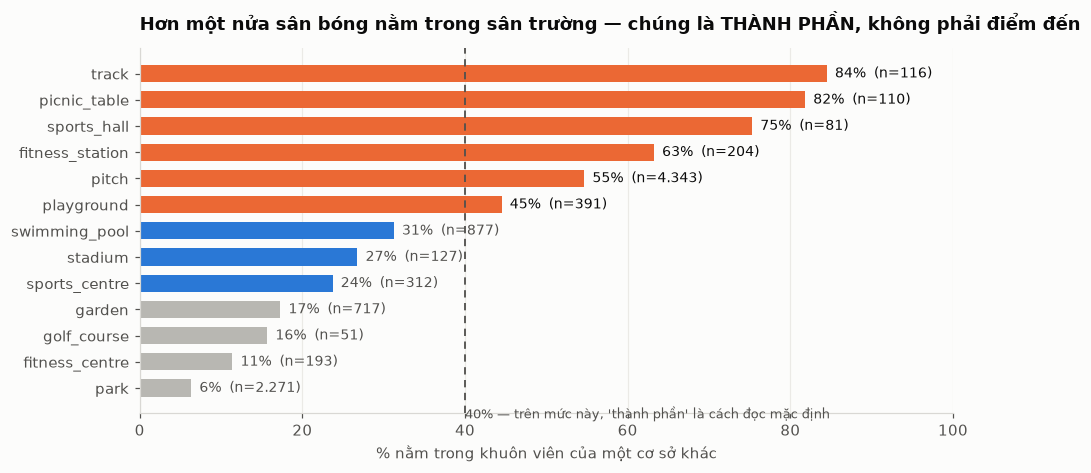

In [7]:
import matplotlib.pyplot as plt
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


# KHUÔN VIÊN CHỦ: polygon của một cơ sở có ranh giới, đủ lớn để chứa tiện ích bên trong.
# Lấy từ BỘ GỐC (`poi`) chứ không từ tập tuyển — trường học và bệnh viện chưa được bóc ra,
# và chúng chính là chủ nhà quan trọng nhất.
CHU_AMENITY = [
    "school",
    "university",
    "college",
    "kindergarten",
    "hospital",
    "prison",
    "community_centre",
    "place_of_worship",
]
CHU_LEISURE = ["sports_centre", "stadium", "park", "recreation_ground", "golf_course", "water_park"]
chu = poi[
    poi["is_area"]
    & poi["geometry_wkb"].notna()
    & (
        poi["amenity"].isin(CHU_AMENITY)
        | poi["leisure"].isin(CHU_LEISURE)
        | poi["landuse"].isin(["education", "military", "recreation_ground", "religious"])
    )
].copy()
chu["_geom"] = [wkb.loads(bytes(x)) for x in chu["geometry_wkb"]]
chu = chu[[g.is_valid and g.area > 0 for g in chu["_geom"]]]
print(f"khuôn viên chủ dựng từ bộ gốc: {len(chu):,} polygon")

PTS = [Point(x, y) for x, y in zip(gt["lng"].values, gt["lat"].values)]
TREE = STRtree(PTS)
GT_UID = gt["uid"].values
ben_trong = {}
# duyệt từ TO xuống NHỎ ⇒ khuôn viên sát nhất ghi đè
for i, geom in chu.sort_values("area_m2", ascending=False)["_geom"].items():
    host_uid = chu.at[i, "uid"]
    q = TREE.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS[k]) for k in q]]:
        if GT_UID[j] != host_uid:
            ben_trong[GT_UID[j]] = host_uid

gt["ben_trong_uid"] = gt["uid"].map(ben_trong)
_host_loai = poi.set_index("uid").reindex(gt["ben_trong_uid"])
gt["ben_trong_loai"] = np.where(
    _host_loai["amenity"].notna().values,
    "amenity:" + _host_loai["amenity"].fillna("").values,
    np.where(
        _host_loai["leisure"].notna().values,
        "leisure:" + _host_loai["leisure"].fillna("").values,
        "landuse:" + _host_loai["landuse"].fillna("").values,
    ),
)
gt.loc[gt["ben_trong_uid"].isna(), "ben_trong_loai"] = None

print(
    f"\nnằm TRONG một khuôn viên khác: {gt['ben_trong_uid'].notna().sum():,}"
    f" ({gt['ben_trong_uid'].notna().mean():.0%})"
)
print("\ntỷ lệ nằm trong, theo loại tiện ích:")
vai = gt.groupby("leisure").agg(
    n=("ben_trong_uid", "size"), trong=("ben_trong_uid", lambda s: s.notna().mean())
)
vai = vai[vai["n"] >= 40].sort_values("trong", ascending=False)
print(vai.assign(trong=lambda d: (d.trong * 100).round(1)).to_string())
print("\nchủ nhà hay gặp:", gt["ben_trong_loai"].value_counts().head(8).to_dict())

fig, ax = plt.subplots(figsize=(9, 4.4))
v = vai.sort_values("trong")
cols = [ORANGE if t >= 0.4 else (BLUE if t >= 0.2 else GRAY) for t in v["trong"]]
ax.barh(v.index, v["trong"] * 100, color=cols, height=0.66)
ax.axvline(40, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)), zorder=4)
ax.annotate(
    "40% — trên mức này, 'thành phần' là cách đọc mặc định",
    (40, -0.7),
    ha="left",
    va="top",
    fontsize=8.5,
    color=MUTED,
)
for y, (t, n) in enumerate(zip(v["trong"], v["n"])):
    ax.text(
        t * 100 + 1,
        y,
        f"{t:.0%}  (n={fmt(n)})",
        va="center",
        fontsize=9,
        color=INK if t >= 0.4 else MUTED,
    )
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.set_xlabel("% nằm trong khuôn viên của một cơ sở khác")
ax.set_title(
    "Hơn một nửa sân bóng nằm trong sân trường — chúng là THÀNH PHẦN, không phải điểm đến",
    pad=12,
    loc="left",
)
fig.tight_layout()
plt.show()

### REVIEW — vai trò không gian

**Soi gì:** quan hệ bao-chứa giữa tiện ích giải trí và khuôn viên trường / bệnh viện /
trung tâm thể thao / công viên, dựng từ **bộ gốc** (trường học chưa bị bóc ra nên còn đủ).

**Tìm được:** thứ tự rất rõ và khớp với thực địa — `track` 84,5% · `fitness_station` 63,2% ·
`pitch` 54,7% · `playground` 44,5% nằm trong khuôn viên khác, so với `swimming_pool` 31,2%
và `garden` 17,3%. Đường chạy điền kinh gần như không bao giờ đứng một mình; bể bơi thì có.

**Quyết định:** tiện ích thuộc nhóm THÀNH PHẦN (`pitch`, `track`, `fitness_station`,
`playground`, `swimming_pool`) **và** nằm trong khuôn viên khác **và** không có tên riêng
⇒ loại khỏi lớp, `drop_reason = "THANH_PHAN_KHUON_VIEN"`. Có tên riêng thì giữ: người map
đặt tên nghĩa là họ coi nó là một nơi.

**Vì sao đây là quyết định ĐÚNG chứ không phải tiện tay:** không loại thì lớp trường học
(chạy sau) sẽ đếm lại chính khuôn viên đó, và bài toán trạm sạc sẽ thấy hai điểm cầu ở
cùng một chỗ. Đây là biến thể của bài học `container_uid` ở lớp nhà ở, khác ở chỗ nó xảy
ra **giữa hai lớp** chứ không trong một lớp.

*(Bốn số giữa đã sửa theo output ngay trên — bản trước chép tay từ một lần chạy cũ.
Thứ hạng không đổi, kết luận không đổi.)*

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: mỗi luật một cell

In [8]:
candidates = gt.copy()
remaining = candidates.copy()
remaining["mixed_use"] = False
removed_parts = []

LOAI_DIEM_DEN = [
    "park",
    "stadium",
    "sports_centre",
    "sports_hall",
    "golf_course",
    "water_park",
    "amusement_arcade",
    "marina",
    "fitness_centre",
    "dance",
    "bowling_alley",
    "ice_rink",
    "horse_riding",
    "nature_reserve",
    "beach_resort",
]


def co_bang_chung_diem_den(df, cho_phep_ten=True):
    """Bằng chứng ĐIỂM ĐẾN: loại hình tự nó là điểm đến, hoặc TÊN GIẢI TRÍ + đủ lớn.

    Mệnh đề TÊN đòi tên khớp `GT_RX_DIEM_DEN`, không phải "có tên bất kỳ". Bản trước dùng
    `name.notna() & area>=2000` — một lệnh ân xá vô điều kiện: mọi thứ TO + CÓ TÊN đều
    bất khả xâm phạm, kể cả khi tên nói thẳng nó là lớp khác.

    `cho_phep_ten=False` tắt hẳn mệnh đề tên, chỉ còn bằng chứng TAG. Dùng cho các luật mà
    cái TÊN đang đóng vai BẰNG CHỨNG BUỘC TỘI ("KCN Bàu Xéo", "Nghĩa trang Công viên Châu
    Đức"): không thể để chính chuỗi ký tự vừa kết tội đứng ra ân xá.
    """
    bc = (
        df["leisure"].isin(LOAI_DIEM_DEN)
        | df["tourism"].isin(["theme_park", "zoo", "aquarium"])
        | df["building"].isin(["stadium", "sports_hall", "sports_centre"])
    )
    if cho_phep_ten:
        bc = bc | (
            df["name_norm"].str.contains(GT_RX_DIEM_DEN, regex=True, na=False)
            & df["area_m2"].fillna(0).ge(2_000)
        )
    return bc


def drop_rule(cond, rule, n=6, tha_diem_den=False):
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)
    if tha_diem_den:
        tha = m & co_bang_chung_diem_den(remaining)
        if tha.any():
            remaining.loc[tha, "mixed_use"] = True
            print(
                f"  ⊙ {tha.sum()} dòng có bằng chứng ĐIỂM ĐẾN → GIỮ, cờ mixed_use:",
                remaining.loc[tha, "name"].dropna().head(5).tolist(),
            )
            m = m & ~tha
    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())
    conflict = hit[co_bang_chung_diem_den(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng có bằng chứng điểm đến:",
            conflict["name"].dropna().head(8).tolist(),
        )
    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


print(f"vào bước 3: {len(remaining):,} dòng")

vào bước 3: 17,306 dòng


In [9]:
# LUẬT 1 — hạ tầng đường. Luật số 1 của bốn lớp liên tiếp.
#
# `tha_diem_den=True` là bắt buộc ở lớp NÀY, khác ba lớp trước. Lý do: OSM vẽ QUẢNG TRƯỜNG
# bằng `highway=pedestrian` (polygon), và trường đua bằng `highway=raceway` — hai loại điểm
# đến thuần tuý mang tag của họ `highway`. Bản trước cắt thẳng, mất "Quảng trường Bãi Sau",
# "Quảng trường Cá voi", "Quảng trường Mặt Trời", "Trường đua đường phố Hà Nội" (338.000 m²).
# Ân xá đòi TÊN khớp GT_RX_DIEM_DEN **và** ≥ 2.000 m², nên nó không mở cửa lại cho 182 điểm
# dừng xe buýt mang tên "Công viên Thống Nhất - Đối diện 326 Lê Duẩn": chúng là NODE, dt = 0.
# Đây là ranh giới "vật thể mang tên mốc" vs "chính cái mốc" — đo bằng diện tích.
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print()
drop_rule(INFRA, "HA_TANG_DUONG", tha_diem_den=True)



  ⊙ 6 dòng có bằng chứng ĐIỂM ĐẾN → GIỮ, cờ mixed_use: ['Trường đua đường phố Hà Nội', 'Quảng trường Bãi Sau', 'Ga Công Viên Văn Thánh', 'Ha Noi Super Karting', 'Quảng trường Mặt Trời']
HA_TANG_DUONG: xoá 342  →  còn lại 16,964
  mẫu : ['Công viên Thống Nhất - Đối diện 326 Lê Duẩn', '73 Văn Cao - Đối diện Cung thể thao Quần Ngựa', '3 Thái Hà - Bể bơi Thái Hà', 'Công viên Thống Nhất', 'Công viên Tuổi Trẻ', 'Đối diện Công viên Thủ Lệ - Đường Bưởi dưới']


In [10]:
# LUẬT 2 — MẶT PHỦ, không phải cơ sở. `landuse=grass` là lớp phủ mặt đất: dải phân cách,
# bồn cỏ vòng xoay, thảm cỏ trong khuôn viên. Nó KHÔNG phải một nơi.
# Vẫn tha dòng có tên + đủ lớn: "Vườn hoa Lý Thái Tổ" là `landuse=grass` nhưng là một nơi thật.
MAT_PHU = remaining["landuse"].isin(["grass", "village_green"]) & remaining["leisure"].isna()
print(
    "mặt phủ — diện tích trung vị:",
    f"{remaining.loc[MAT_PHU & remaining['is_area'], 'area_m2'].median():,.0f} m²",
    "| có tên:",
    f"{remaining.loc[MAT_PHU, 'name'].notna().mean():.1%}",
)
print()
drop_rule(MAT_PHU, "MAT_PHU_KHONG_PHAI_CO_SO", tha_diem_den=True)

mặt phủ — diện tích trung vị: 362 m² | có tên: 0.1%



  ⊙ 3 dòng có bằng chứng ĐIỂM ĐẾN → GIỮ, cờ mixed_use: ['Quảng Trường Sinh Viên', 'Trung tâm TDTT huyện Mỹ Xuyên', 'Sân tập Golf Sonadezi']
MAT_PHU_KHONG_PHAI_CO_SO: xoá 6,221  →  còn lại 10,743
  mẫu : ['Vòng xoay Paradise', 'sân', 'Vườn Vải', 'Vườn thực vật', 'Di tích Thành cổ Biên Hòa', 'Ngã ba Thánh Mẫu']


In [11]:
# LUẬT 3 — THÀNH PHẦN CỦA KHUÔN VIÊN KHÁC. Luật đặc trưng của lớp này (xem bước 2).
# Ba điều kiện phải cùng đúng: loại hình là tiện ích thành phần, nằm trong khuôn viên khác,
# và KHÔNG có tên riêng. Tên riêng là quyền phủ quyết — người map đặt tên nghĩa là một nơi.
LOAI_THANH_PHAN = [
    "pitch",
    "track",
    "fitness_station",
    "playground",
    "swimming_pool",
    "picnic_table",
    "outdoor_seating",
    "bleachers",
    "firepit",
    "bandstand",
]
THANH_PHAN = (
    remaining["leisure"].isin(LOAI_THANH_PHAN)
    & remaining["ben_trong_uid"].notna()
    & remaining["name"].isna()
)
print(
    "phân theo loại chủ nhà:",
    remaining.loc[THANH_PHAN, "ben_trong_loai"].value_counts().head(8).to_dict(),
)
print()
drop_rule(THANH_PHAN, "THANH_PHAN_KHUON_VIEN", n=4)

phân theo loại chủ nhà: {'amenity:school': 787, 'leisure:park': 583, 'leisure:sports_centre': 467, 'amenity:university': 315, 'landuse:military': 303, 'landuse:recreation_ground': 124, 'amenity:college': 104, 'leisure:stadium': 94}

THANH_PHAN_KHUON_VIEN: xoá 2,948  →  còn lại 7,795
  mẫu : []


In [12]:
# LUẬT 4 — QUÁ NHỎ VÀ VÔ DANH. Sau khi đã gỡ mặt phủ và thành phần, phần còn lại vẫn đầy
# polygon tí hon vô danh (bồn hoa, sân chơi tổ dân phố chưa ai đặt tên).
#
# Ngưỡng 1.000 m² lấy từ ĐIỂM NHẤC của bước chân dung: độ phủ tên nhảy gấp đôi tại đó
# (5,5% → 10,8%). Vẫn là ngưỡng ĐẶT TAY — dữ liệu chỉ ra chỗ nhấc, con số tròn là do người chọn.
NGUONG_DT = 1_000
QUA_NHO = (
    remaining["name"].isna()
    & ~co_bang_chung_diem_den(remaining, cho_phep_ten=False)
    & remaining["is_area"]
    & remaining["area_m2"].lt(NGUONG_DT)
)
# `cho_phep_ten=False`: dòng vô danh thì mệnh đề tên vô nghĩa, nhưng `building=stadium|
# sports_hall|sports_centre` vẫn là bằng chứng — bản trước chỉ chặn theo `leisure` nên
# cắt oan 7 khán đài/nhà thi đấu vô danh (chính cell hậu kiểm đã in ⚠ 7 mà không xử).
print(f"vô danh & < {fmt(NGUONG_DT)} m² & không có bằng chứng điểm đến: {int(QUA_NHO.sum()):,}")
print("  loại hình bị cắt:", remaining.loc[QUA_NHO, "leisure"].value_counts().head(8).to_dict())
print()
drop_rule(QUA_NHO, "QUA_NHO_VO_DANH", n=4)

vô danh & < 1.000 m² & không có bằng chứng điểm đến: 2,250
  loại hình bị cắt: {'pitch': 1054, 'swimming_pool': 477, 'garden': 457, 'playground': 99, 'fitness_station': 13, 'outdoor_seating': 7, 'recreation_ground': 2, 'sport': 1}

QUA_NHO_VO_DANH: xoá 2,250  →  còn lại 5,545
  mẫu : []


In [13]:
# LUẬT 5 — họ tag thuộc LỚP KHÁC. Rạp phim / nhà hát / bảo tàng → lớp THAM QUAN (chạy ngay
# sau); quán bar, hộp đêm → lớp ăn uống; bãi đỗ → transit. Bước 1 không tuyển chúng theo tag,
# nhưng nhánh TÊN có thể kéo vào ("Công viên nước Hồ Tây" thì đúng, "Rạp Công Nhân" thì không).
NGOAI_LOP = (
    remaining["amenity"].isin(
        [
            "cinema",
            "theatre",
            "nightclub",
            "bar",
            "pub",
            "restaurant",
            "cafe",
            "fast_food",
            "parking",
            "fuel",
            "bank",
            "place_of_worship",
            "school",
            "hospital",
            "clinic",
            "marketplace",
            "bus_station",
            "toilets",
            "shelter",
            "waste_basket",
            "drinking_water",
            # bổ sung sau thẩm định: bốn họ này lọt vào final qua nhánh TÊN
            "bicycle_rental",  # trạm xe đạp công cộng TNGo — tên nhắc công viên bên cạnh
            "driving_school",  # "Sân tập lái" khớp token `san tap`
            "library",
        ]
    )
    | remaining["tourism"].isin(
        ["museum", "artwork", "attraction", "viewpoint", "gallery", "hotel"]
    )
    | remaining["shop"].isin(["ticket"])
    | remaining["historic"].notna()
)
print(
    "phân bố:",
    remaining.loc[NGOAI_LOP, "amenity"].value_counts().head(6).to_dict(),
    remaining.loc[NGOAI_LOP, "tourism"].value_counts().head(4).to_dict(),
)
print()
drop_rule(NGOAI_LOP, "TAG_LOP_KHAC", tha_diem_den=True)

phân bố: {'bicycle_rental': 16, 'parking': 12, 'bar': 12, 'cafe': 6, 'restaurant': 5, 'school': 5} {'attraction': 13, 'artwork': 4, 'museum': 3, 'viewpoint': 1}

  ⊙ 15 dòng có bằng chứng ĐIỂM ĐẾN → GIỮ, cờ mixed_use: ['The Commons Thu Thiem', 'Khu du lịch Thác Giang Điền', 'Vườn Bàng', 'Địa đạo Bến Đình', 'Công viên Bãi Trước']
TAG_LOP_KHAC: xoá 87  →  còn lại 5,458
  mẫu : ['Quảng trường Sao Đỏ', 'Vườn Đào', 'Imperial Car Park', 'Công Viên Ven Sông An Phú Hưng', 'VN BD Công Viên', 'Công viên']


In [14]:
# LUẬT 6 — tên nói thẳng đây là loại khác. Danh sách HẸP, và tách LÀM HAI TẦNG.
# KHÔNG có "san " trần: nó khớp "Sản", "Sàn", và cả tên riêng ("Sang", "Sanh" sau khi bỏ dấu
# vẫn còn ranh giới nên `\bsan\b` an toàn, nhưng "san" đứng riêng thì hầu hết là nhiễu).
#
# Vì sao hai tầng: quyền ân xá của `co_bang_chung_diem_den` cũng đọc cái TÊN. Nếu để nó áp
# lên cả luật này thì cái tên vừa buộc tội vừa gỡ tội — "Nghĩa trang Công viên Châu Đức"
# (168.000 m²) trúng `nghia trang` rồi được `cong vien` tha ngay trong một dòng. Nhưng tắt
# ân xá cho TOÀN BỘ danh sách thì cắt oan chiều ngược lại: `\bdinh \b` khớp "Ba **Đình**",
# `\bden \b` khớp "**Đền** Lừ", `\bdinh \b` khớp "**Định** Công" — bỏ dấu xong thì đền/đình/
# chùa (nơi thờ tự) và Đình/Định (địa danh) là cùng một chuỗi ký tự.
#
#   CỨNG — tên TỰ KHAI loại hình, không nhập nhằng được. Thắng mọi ân xá.
TEN_CUNG = (
    r"benh vien|phong kham|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc|cao dang)"
    r"|\bubnd\b|uy ban nhan dan|\bcong an\b|nha may|xi nghiep|\bkcn\b|khu cong nghiep"
    r"|nghia trang|nghia dia|\brap \b|nha hat|bao tang|nha tang le"
    # audit diện tích: 3 KHU CÔNG NGHỆ CAO (Hoà Lạc 12,3 km², TP.HCM 8,6, Đà Nẵng 5,5)
    # vẫn nằm trong final — vào bằng `\bpark\b` qua `alt_name` "…Hi-Tech Park", và
    # `khu cong nghiep` không khớp "khu công nghệ cao". Cùng họ, phải chặn cùng chỗ.
    r"|khu cong nghe cao|hi-? ?tech park|khu che xuat|cum cong nghiep|khu cong nghe"
    # [VÁ bổ sung 2026-08-09] cùng họ `\bpark\b`-qua-alt_name, đo trên final SAU vòng vá
    # trước còn sót: "Danang Industrial Park" (landuse=industrial), "Imperia/Picity Sky
    # Park" (dự án nhà ở), "Novaland The Park Avenue", "Trạm xử lý nước thải Vinhomes
    # Grand Park". Tầng CỨNG vẫn tha dòng có bằng chứng TAG (cho_phep_ten=False), nên
    # "Botanica Premier Residential Park" / "Công viên KDC Nam Long" (leisure=park) Ở LẠI.
    r"|industrial park|logistics park|business park|software park|residential park"
    r"|sky park|park avenue|tram xu ly"
    r"|bai do xe|\bnha xe\b|ben xe|cay xang|tram xang|khach san|nha nghi"
)
#   MỀM — token nhập nhằng vì mất dấu. Giữ nguyên quyền ân xá: có tên giải trí + đủ lớn
#   thì tên giải trí thắng, "Quảng trường Ba Đình" ở lại.
TEN_MEM = r"nha tho|\bchua \b|\bdinh \b|\bden \b"
# Tầng MỀM thua BẤT KỲ bằng chứng TAG nào, KHÔNG đòi ngưỡng diện tích. Audit phần bị xoá
# cho thấy vì sao: "Sân Pickleball Đền Lừ" (`leisure=pitch`, `sport=pickleball`, 1.464 m²)
# và 8 sân khác ở Định Công / Đền Lừ bị cắt oan — chúng CÓ tag thể thao rõ ràng, chỉ thua
# vì < 2.000 m² nên không với tới ngưỡng ân xá. Với một token nhập nhằng do mất dấu, một
# cái tag bất kỳ đã đủ để lật: `\bden \b` không bao giờ thắng nổi `sport=pickleball`.
BANG_CHUNG_TAG = (
    remaining["leisure"].notna()
    | remaining["sport"].notna()
    | remaining["building"].isin(["stadium", "sports_hall", "sports_centre", "grandstand"])
    | remaining["amenity"].eq("community_centre")
)

nn_r = remaining["name_norm"]
TEN_LOAI_KHAC = (
    nn_r.str.contains(TEN_CUNG, regex=True, na=False)
    & ~co_bang_chung_diem_den(remaining, cho_phep_ten=False)
) | (
    nn_r.str.contains(TEN_MEM, regex=True, na=False)
    & ~co_bang_chung_diem_den(remaining)
    & ~BANG_CHUNG_TAG
)
print(
    "  tầng CỨNG",
    int(nn_r.str.contains(TEN_CUNG, regex=True, na=False).sum()),
    "| tầng MỀM",
    int(nn_r.str.contains(TEN_MEM, regex=True, na=False).sum()),
    "(trước ân xá)",
)
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


  tầng CỨNG 41 | tầng MỀM 38 (trước ân xá)
TEN_LOAI_KHAC: xoá 36  →  còn lại 5,422
  mẫu : ['Khu Nội Trú Lưu Học Sinh Lào - Trường Đại Học SP TDTT Hà Nội', 'Câu lạc bộ bóng đá Công an Hà Nội', 'Khu công nghiệp Sài Đồng B', 'Danang Industrial Park', 'Cong an', 'Quảng trường Nhà Hát Lớn']
  ⚠ 4 dòng có bằng chứng điểm đến: ['Nghĩa trang Công viên Châu Đức', 'Công viên Nghĩa trang Phúc An Viên', 'Trung tâm Văn hóa - Thông tin và Thể thao phường Đông Ngạc', 'Công Viên Nghĩa Trang Sala Garden']


In [15]:
# LUẬT 7 — MỐC THAM CHIẾU.
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 5,422
  mẫu : []


In [16]:
# LUẬT 8 — CHỈ VÀO BẰNG TÊN, mà lại MANG TAG CHỨC NĂNG CỦA LỚP KHÁC.
# Nhánh C tuyển bằng `name_norm`, và `name_norm` gộp cả `name:en`/`alt_name`/địa chỉ. Hệ quả
# đo được: `\bpark\b` kéo vào "Bau Xeo Industrial Park" (5,3 km² KCN), "Imperia Sky Park"
# (chung cư); `san tap` kéo "Sân tập lái". Mẫu 30 dòng nhóm này sai 12.
# Cổng: không có MỘT tag giải trí nào (cả lớp đứng trên một chuỗi ký tự) mà lại có
# `amenity`/`shop`/`office` — thì cái TAG thắng cái TÊN. Đây là bẫy 3 của chuỗi: tag mô tả
# vật thể, tên chỉ là mốc tham chiếu.
# KHÔNG `tha_diem_den`: mệnh đề tên của `co_bang_chung_diem_den` chính là thứ vừa kéo chúng
# vào, để nó ân xá thì luật này tự vô hiệu.
AMENITY_GT_OK = ["swimming_pool", "community_centre", "dojo", "gym", "public_bath"]
# [VÁ bổ sung 2026-08-09] thêm 3 họ tag đo được còn lọt sau vòng vá trước — vẫn trên
# dòng CHỈ-vào-bằng-tên: `tourism` ("National Park station" tourism=information),
# `building` văn phòng/thương mại ("Techno Park Tower", "National Park Ranger" ×2,
# "Sky Park Residence"), `landuse=industrial` ("Danang Industrial Park").
# KHÔNG đụng `landuse=construction`: lỗi #4 của CHỐT đã quyết giữ + cắm cờ nhóm
# "công viên chưa xây" ("Dự án Xây dựng công viên… Thạch Bàn"), không xoá ở đây.
CHI_TEN_TAG_KHAC = (
    remaining["gt_chi_ten"]
    & (
        remaining["amenity"].notna()
        | remaining["shop"].notna()
        | remaining["office"].notna()
        | remaining["tourism"].notna()
        | remaining["building"].isin(["office", "commercial", "industrial", "warehouse", "retail"])
        | remaining["landuse"].isin(["industrial"])
    )
    & ~remaining["amenity"].isin(AMENITY_GT_OK)
)
print(
    "tag chức năng thắng cái tên:",
    remaining.loc[CHI_TEN_TAG_KHAC, "amenity"].value_counts().head(6).to_dict(),
    remaining.loc[CHI_TEN_TAG_KHAC, "shop"].value_counts().head(4).to_dict(),
    remaining.loc[CHI_TEN_TAG_KHAC, "office"].value_counts().head(3).to_dict(),
)
print()
drop_rule(CHI_TEN_TAG_KHAC, "CHI_TEN_TAG_LOP_KHAC")


tag chức năng thắng cái tên: {'driver_training': 2, 'townhall': 1, 'hunting_stand': 1, 'casino': 1, 'police': 1, 'public_building': 1} {'sports': 4, 'convenience': 3, 'travel_agency': 2, 'electronics': 1} {'company': 3, 'it': 2, 'forestry': 1}

CHI_TEN_TAG_LOP_KHAC: xoá 51  →  còn lại 5,371
  mẫu : ['Trung tâm Văn hóa Thể thao Thạnh Trị', 'Golf', 'National Park station & Bay Management staton', 'Hồ Bơi-Tennis', 'Điện Tử Quang Trường', 'Khu vui chơi, mua sắm Zakka']
  ⚠ 5 dòng có bằng chứng điểm đến: ['Nhà thi đấu đa năng Thành phố Cần Thơ', 'Sân Golf Tân Sơn Nhất', 'Trường TDTT Quảng Ninh', 'Quảng trường Ba Đình', 'Trường Trung học phổ thông Chuyên năng khiếu TDTT Nguyễn Thị Định']


In [17]:
# CỔNG HẬU KIỂM.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

LUAT_CO_Y = {
    "MAT_PHU_KHONG_PHAI_CO_SO",
    "THANH_PHAN_KHUON_VIEN",
    "QUA_NHO_VO_DANH",
    "TAG_LOP_KHAC",
    "CHI_TEN_TAG_LOP_KHAC",
}
conflict = removed[co_bang_chung_diem_den(removed)]
print(f"POI có bằng chứng ĐIỂM ĐẾN nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string() or "  (không có)")
cf_ngoai_y = conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── do LUẬT NGOÀI Ý (phải nhỏ): {len(cf_ngoai_y)} ──")
if len(cf_ngoai_y):
    print(cf_ngoai_y[["name", "leisure", "amenity", "area_m2", "drop_reason"]].head(25).to_string())
assert len(cf_ngoai_y) <= 30, f"{len(cf_ngoai_y)} dòng điểm đến bị luật NGOÀI Ý xoá"

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== nhóm rủi ro nhất: tên có 'công viên/sân vận động' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"cong vien|san van dong", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(8).tolist())

POI có bằng chứng ĐIỂM ĐẾN nhưng bị xoá: 9 — phân theo luật:
drop_reason
CHI_TEN_TAG_LOP_KHAC    5
TEN_LOAI_KHAC           4

── do LUẬT NGOÀI Ý (phải nhỏ): 4 ──
                                                              name leisure           amenity        area_m2    drop_reason
120515                              Nghĩa trang Công viên Châu Đức     NaN               NaN  167999.493283  TEN_LOAI_KHAC
120611                          Công viên Nghĩa trang Phúc An Viên     NaN               NaN  189148.534327  TEN_LOAI_KHAC
124878  Trung tâm Văn hóa - Thông tin và Thể thao phường Đông Ngạc     NaN  community_centre    2685.350900  TEN_LOAI_KHAC
130709                           Công Viên Nghĩa Trang Sala Garden     NaN               NaN  500517.193897  TEN_LOAI_KHAC

== tổng hợp theo luật ==
drop_reason
MAT_PHU_KHONG_PHAI_CO_SO    6221
THANH_PHAN_KHUON_VIEN       2948
QUA_NHO_VO_DANH             2250
HA_TANG_DUONG                342
TAG_LOP_KHAC                  87
CHI_TEN_TAG_LOP_KHAC

In [18]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_{LOP}_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")
print("tỷ lệ sống sót theo nhánh tuyển:")
for ten, m in BR.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:24s} {song:5,}/{tong:<6,} = {song / tong:.0%}" if tong else f"  {ten:24s} —")

giữ : 5,371 → poi_giaitri_7tinh_b3.parquet
xoá : 11,935 → poi_giaitri_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển:
  A tag giải trí           5,072/10,170 = 50%
  B đất công cộng            122/6,456  = 2%
  C tên                    1,528/2,015  = 76%
  D sport không leisure       83/106    = 78%
  E vòng đời                   4/5      = 80%


## Bước 4 — ĐO, không quyết

hang_gt
CONG_VIEN              2402
CO_SO_THE_THAO         1998
TIEN_ICH_KHU_DAN_CU     403
SAN_VAN_DONG            213
KHAC                    192
KHU_VUI_CHOI            111
QUANG_TRUONG             37
THIEN_NHIEN              15

quy_mo_gt            KHONG_DO_DUOC  LON_TREN_2HA  NHO_DUOI_2000M2  VUA_2000_20000M2
hang_gt                                                                            
CONG_VIEN                       80           255              907              1160
CO_SO_THE_THAO                 416            94              925               563
KHAC                            76            10               54                52
KHU_VUI_CHOI                    42            26               19                24
QUANG_TRUONG                    13             6                3                15
SAN_VAN_DONG                    17            35               41               120
THIEN_NHIEN                      0            15                0                 0
TIEN_ICH_KH

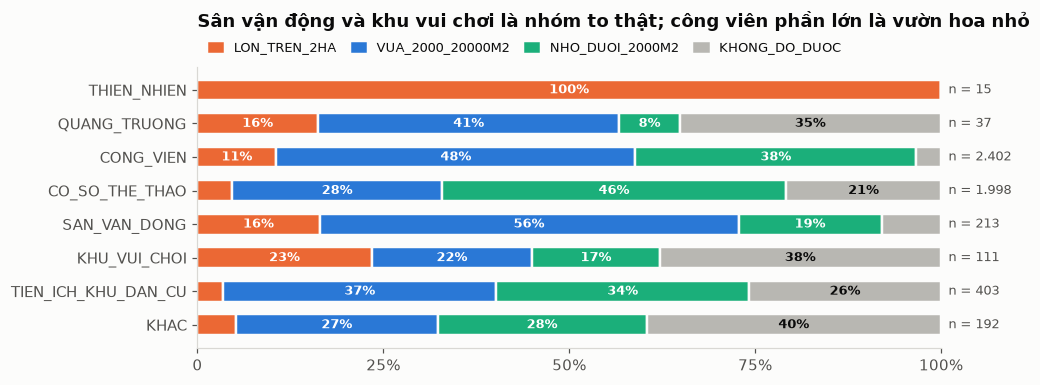

In [19]:
# [DATA] sinh cột: hang_gt, quy_mo_gt, vai_tro
nn_c = clean["name_norm"]
hang = pd.Series("KHAC", index=clean.index)
for cond, val in [
    # `leisure=nature_reserve` phải RA KHỎI CONG_VIEN. 15 dòng này (Vườn quốc gia Cát Bà,
    # Bù Gia Mập, Bái Tử Long, Khu bảo tồn Đồng Nai 990 km²…) chiếm **96,7% toàn bộ diện
    # tích lớp** trên 0,28% số dòng. Gộp chung thì mọi phép "trạm sạc nằm trong công viên"
    # đều đúng cho nửa Đà Nẵng, và mọi thống kê theo diện tích đều là thống kê về rừng.
    (
        clean["leisure"].eq("nature_reserve")
        | nn_c.str.contains(r"vuon quoc gia|khu bao ton|rung dac dung|khu du tru sinh quyen", na=False),
        "THIEN_NHIEN",
    ),
    # Quảng trường là hình thái RIÊNG, không phải công viên: mặt lát, không cây, nhu cầu đỗ
    # xe theo SỰ KIỆN chứ không theo ngày. `quang truong` cũng là token độc quyền nhất còn
    # lại của GT_RX (50/52 dòng không token nào khác đỡ) — tách ra thì soi được nó riêng.
    (
        nn_c.str.contains(r"quang truong", na=False) & clean["leisure"].isna(),
        "QUANG_TRUONG",
    ),
    # `leisure=stadium` KHÔNG đủ để gọi là sân vận động. Audit bắt được "Sân Cầu Lông TamBo"
    # (792 m², `sport=badminton`) và "sân bóng đường số 4" (582 m²) mang nhãn SAN_VAN_DONG.
    # Sân đơn môn nhỏ hơn 2.000 m² là SÂN, không phải SÂN VẬN ĐỘNG.
    (
        (
            clean["leisure"].eq("stadium")
            | clean["building"].eq("stadium")
            | nn_c.str.contains(r"san van dong|\bsvd\b|\bstadium\b", na=False)
        )
        & ~(
            clean["sport"].isin(["badminton", "basketball", "volleyball", "table_tennis", "pickleball"])
            & clean["area_m2"].fillna(0).lt(2_000)
        ),
        "SAN_VAN_DONG",
    ),
    (
        clean["leisure"].isin(["water_park", "amusement_arcade"])
        | clean["tourism"].isin(["theme_park", "zoo", "aquarium"])
        | nn_c.str.contains(
            r"khu vui choi|cong vien nuoc|water ?park|theme ?park|khu giai tri|thao cam vien",
            na=False,
        ),
        "KHU_VUI_CHOI",
    ),
    (
        clean["leisure"].eq("park")
        | clean["landuse"].eq("recreation_ground")
        | nn_c.str.contains(r"cong vien|vuon hoa|quang truong", na=False),
        "CONG_VIEN",
    ),
    (
        clean["leisure"].isin(
            [
                "sports_centre",
                "sports_hall",
                "fitness_centre",
                "golf_course",
                "pitch",
                "track",
                "swimming_pool",
                "horse_riding",
                "ice_rink",
                "bowling_alley",
            ]
        )
        | clean["sport"].notna()
        | nn_c.str.contains(
            r"nha thi dau|san the thao|trung tam the thao|san golf|be boi|ho boi|san tap"
            r"|\btdtt\b|karting|go-?kart|dua xe",
            na=False,
        ),
        "CO_SO_THE_THAO",
    ),
    (
        clean["leisure"].isin(["playground", "garden", "picnic_table", "fitness_station"]),
        "TIEN_ICH_KHU_DAN_CU",
    ),
]:
    hang[cond & hang.eq("KHAC")] = val
clean["hang_gt"] = hang
clean["vai_tro"] = np.where(clean["ben_trong_uid"].notna(), "THANH_PHAN", "CHINH_THE")

_dt = clean["area_m2"].fillna(0)
clean["quy_mo_gt"] = np.select(
    [_dt.ge(20_000), _dt.ge(2_000), _dt.gt(0)],
    ["LON_TREN_2HA", "VUA_2000_20000M2", "NHO_DUOI_2000M2"],
    default="KHONG_DO_DUOC",
)

print(clean["hang_gt"].value_counts().to_string())
print()
print(pd.crosstab(clean["hang_gt"], clean["quy_mo_gt"]).to_string())
print(f"\nvai trò: {clean['vai_tro'].value_counts().to_dict()}")
print(
    f"có tên: {clean['name'].notna().mean():.0%}  (tập tuyển thô là {gt['name'].notna().mean():.0%}"
    " — lọc đã đẩy độ phủ tên lên, dấu hiệu lọc đúng hướng)"
)

fig, ax = plt.subplots(figsize=(9.4, 3.6))
QM = ["LON_TREN_2HA", "VUA_2000_20000M2", "NHO_DUOI_2000M2", "KHONG_DO_DUOC"]
QM_C = {
    "LON_TREN_2HA": ORANGE,
    "VUA_2000_20000M2": BLUE,
    "NHO_DUOI_2000M2": GREEN,
    "KHONG_DO_DUOC": GRAY,
}
HG = [
    h
    for h in [
        "THIEN_NHIEN",
        "QUANG_TRUONG",
        "CONG_VIEN",
        "CO_SO_THE_THAO",
        "SAN_VAN_DONG",
        "KHU_VUI_CHOI",
        "TIEN_ICH_KHU_DAN_CU",
        "KHAC",
    ]
    if h in set(clean["hang_gt"])
]
tab = pd.crosstab(clean["hang_gt"], clean["quy_mo_gt"]).reindex(index=HG, columns=QM).fillna(0)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for q in QM:
    v = share[q].values
    ax.barh(tab.index, v, left=left, color=QM_C[q], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, p in enumerate(v):
        if p > 0.08:
            ax.text(
                left[y] + p / 2,
                y,
                f"{p:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if q != "KHONG_DO_DUOC" else INK,
                fontweight="bold",
            )
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title(
    "Sân vận động và khu vui chơi là nhóm to thật; công viên phần lớn là vườn hoa nhỏ",
    pad=26,
    loc="left",
)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=QM_C[q]) for q in QM],
    labels=QM,
    ncol=4,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=8.5,
    handlelength=1.1,
    columnspacing=1.2,
)
fig.tight_layout()
plt.show()

In [20]:
# [DATA] sinh cột: container_uid, fragment_group
container = {}
vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]
PTS2 = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE2 = STRtree(PTS2)
UIDS2 = clean["uid"].values
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    q = TREE2.query(geom)
    if not len(q):
        continue
    for j in q[[geom.contains(PTS2[k]) for k in q]]:
        if UIDS2[j] != self_uid:
            container[UIDS2[j]] = self_uid
clean["container_uid"] = clean["uid"].map(container)
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"dòng nằm trong polygon giải trí khác: {n_ct:,} → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,}"
)
print(
    f"nhóm trùng tên cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)

dòng nằm trong polygon giải trí khác: 697 → đếm CƠ SỞ: 4,674 thay vì 5,371
nhóm trùng tên cùng ô H3: 57 nhóm, 138 dòng


## Bước 5 — FINAL và bộ CÒN LẠI

In [21]:
final = clean.copy()
out_final = EDA_DIR / f"poi_{LOP}_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nhang_gt  :", final["hang_gt"].value_counts().to_dict())
print("quy_mo_gt:", final["quy_mo_gt"].value_counts().to_dict())
print("vai_tro  :", final["vai_tro"].value_counts().to_dict())
print(f"số CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(
    final.groupby("hang_gt")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 5,371 dòng, 61 cột → poi_giaitri_7tinh_final.parquet

hang_gt  : {'CONG_VIEN': 2402, 'CO_SO_THE_THAO': 1998, 'TIEN_ICH_KHU_DAN_CU': 403, 'SAN_VAN_DONG': 213, 'KHAC': 192, 'KHU_VUI_CHOI': 111, 'QUANG_TRUONG': 37, 'THIEN_NHIEN': 15}
quy_mo_gt: {'NHO_DUOI_2000M2': 2086, 'VUA_2000_20000M2': 2082, 'KHONG_DO_DUOC': 748, 'LON_TREN_2HA': 455}
vai_tro  : {'CHINH_THE': 4645, 'THANH_PHAN': 726}
số CƠ SỞ (lọc container_uid): 4,674

hang_gt                CONG_VIEN  CO_SO_THE_THAO  KHAC  KHU_VUI_CHOI  QUANG_TRUONG  SAN_VAN_DONG  THIEN_NHIEN  TIEN_ICH_KHU_DAN_CU
province_name                                                                                                                     
Thành phố Cần Thơ             90              90    14             6             3            13            1                   45
Thành phố Hà Nội             638             911    74            34            14            51            1                  168
Thành phố Hải Phòng          152             

In [22]:
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()
out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_{LOP}.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)
print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")
_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)
for ten_lop in ["chungcu", "luutru", "thuongmai"]:
    f = EDA_DIR / f"poi_{ten_lop}_{SCOPE}_final.parquet"
    giao = set(pq.read_table(f, columns=["uid"]).to_pandas()["uid"]) & da_thuoc_lop
    assert not giao, f"{len(giao)} uid trùng với lớp {ten_lop}"
    print(f"✓ không đếm đôi với lớp {ten_lop}")

_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp THAM QUAN trong bộ còn lại:")
print("  tourism:", _td.map(lambda t: t.get("tourism")).value_counts().head(8).to_dict())
print(
    "  historic:",
    _td.map(lambda t: t.get("historic")).notna().sum(),
    "| amenity=place_of_worship:",
    _td.map(lambda t: t.get("amenity")).eq("place_of_worship").sum(),
    "| cinema:",
    _td.map(lambda t: t.get("amenity")).eq("cinema").sum(),
)

bộ vào    : 176,615
đã bóc ra : 5,371
CÒN LẠI   : 171,244  → poi_extended_7tinh_con_lai_sau_giaitri.parquet


✓ 11,935 dòng bị 7 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp chungcu
✓ không đếm đôi với lớp luutru
✓ không đếm đôi với lớp thuongmai



nguyên liệu lớp THAM QUAN trong bộ còn lại:
  tourism: {'artwork': 503, 'attraction': 476, 'viewpoint': 341, 'information': 201, 'museum': 162, 'apartment': 135, 'hostel': 64, 'picnic_site': 31}
  historic: 781 | amenity=place_of_worship: 3887 | cinema: 99


---

### CHỐT LỚP GIẢI TRÍ

> ⚠ **Con số trong cell này SINH LẠI SAU LẦN CHẠY TỚI.** Vòng vá bổ sung 2026-08-09
> (mở rộng LUẬT 8 thêm `tourism`/`building` văn phòng-thương mại/`landuse=industrial`;
> thêm cụm tiếng Anh *industrial/sky/residential park*, *park avenue*, *trạm xử lý* vào
> tầng CỨNG của LUẬT 6) dự kiến gỡ thêm ~10 dòng sai còn sót của nhánh `\bpark\b`
> (Danang Industrial Park, Imperia/Picity Sky Park, Techno Park Tower, National Park
> Ranger…) — 5.391 và các bảng dưới sẽ xê dịch tương ứng.

Đầu ra: `data/qa/eda/poi_giaitri_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai_sau_giaitri.parquet` cho lớp sau) — **5.391 dòng / 61 cột**.
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| Hạng | Số dòng | Ghi chú |
| --- | --- | --- |
| `CONG_VIEN` | 2.402 | nhãn thô; **phải đọc kèm `quy_mo_gt`** — xem lỗi #2 |
| `CO_SO_THE_THAO` | 2.001 | trộn hai chế độ ngược nhau — xem lỗi #3 |
| `TIEN_ICH_KHU_DAN_CU` | 403 | sân chơi / vườn nội khu |
| `SAN_VAN_DONG` | 213 | đã siết: sân đơn môn < 2.000 m² không được mang nhãn này |
| `KHAC` | 205 | |
| `KHU_VUI_CHOI` | 114 | tỷ lệ có bãi đỗ cao nhất lớp (32%) |
| `QUANG_TRUONG` | 38 | nhu cầu đỗ xe theo **sự kiện**, không theo ngày |
| `THIEN_NHIEN` | 15 | 0,28% số dòng nhưng **97,5% diện tích lớp** — xem lỗi #1 |

`quy_mo_gt`: `VUA_2000_20000M2` 2.088 · `NHO_DUOI_2000M2` 2.088 · `KHONG_DO_DUOC` 756 · `LON_TREN_2HA` 459
`vai_tro`: `CHINH_THE` 4.664 · `THANH_PHAN` 727 → **đếm CƠ SỞ phải lọc `container_uid.isna()` → 4.686**
Bị 8 luật cắt: 11.914 dòng, tất cả nằm lại trong bộ còn lại, truy được bằng `drop_reason`.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **`THIEN_NHIEN` = 3.449 / 3.539 km² của cả lớp** (Cát Bà, Bù Gia Mập, Đồng Nai 990 km²).
   **Mọi thống kê theo diện tích phải loại hạng này ra trước**, nếu không nó là thống kê về
   rừng — và "trạm sạc nằm trong Vườn quốc gia Cát Bà" không nói lên điều gì.
2. **`CONG_VIEN` trộn ba thứ:** công viên > 2 ha (255), vườn hoa khu dân cư (1.160), bồn hoa
   < 2.000 m² (907). Đọc `hang_gt` một mình là sai.
3. **`CO_SO_THE_THAO` trộn hai chế độ, đo được bằng `sport`:** sân thuê theo giờ (soccer,
   1.668 m², 8% là thành phần) và sân trong khuôn viên (bóng rổ, 250 m², 61% là thành phần).
   Nhóm đầu là điểm đến có nhu cầu; nhóm sau là hạ tầng nội bộ, cầu sạc thuộc về chủ khuôn
   viên. `sport` + `vai_tro` tách được ngay, **chưa làm**.
4. **28 dòng `landuse=construction` (3,83 km²) là công viên CHƯA XÂY** — "Công viên Kim Quy"
   86 ha. Điểm đến chưa tồn tại, nên cắm cờ `trang_thai` chứ không xoá. **Chưa làm**, và lớp
   chungcu đang xử lý ngược lại (xoá 138 dòng) — mâu thuẫn liên lớp, cần một quyết định chung.
5. **Ngưỡng 1.000 m² và 2 ha là ĐẶT TAY**, lấy từ điểm nhấc độ phủ tên đo trên 7 tỉnh **đô
   thị** — phải đo lại trước `SCOPE=vn`.

**Giới hạn của NGUỒN**

6. **87% ứng viên thô vô danh, trung vị 1 tag.** Rủi ro chính là *không kiểm chứng được*,
   không phải *sai*: mẫu 50 dòng đọc tay ra ~43 đúng / 4 sai / 3 không kết luận. Nhiễu phép
   ĐẾM, không nhiễu VỊ TRÍ.
7. **`name_norm` gộp `name:en`/`alt_name`/`old_name`** (7,3% bộ vào có trường này). Mọi regex
   tên của cả chuỗi đang chạy trên một trường GỘP — chưa lớp nào khai điều đó ra.

**Đo được, dùng lại cho lớp khác**

8. **Bãi đỗ xe làm proxy "đặt được sạc không"** (`amenity=parking` trong 30 m, STRtree dựng
   từ bộ gốc): nền 11,5% → ≥20.000 m² 30,5% → ≥50.000 m² 40,6%, đơn điệu, không điểm gãy
   ⇒ **diện tích là thang liên tục, đừng cắt bậc**. **CẢNH BÁO: đây là CẬN DƯỚI** — OSM VN vẽ
   bãi đỗ rất thưa (vườn quốc gia = 0). Dùng làm tín hiệu **DƯƠNG**, cấm dùng làm tín hiệu ÂM.

### Bàn giao cho lớp THAM QUAN

Đã **cố ý không tuyển**, còn nguyên trong bộ còn lại: `amenity=cinema` · `tourism=museum` ·
`attraction` · `artwork` · `viewpoint` · `historic=*` · `place_of_worship` · `natural=beach`.
Trục đáng thử ở lớp sau: **tên đa ngôn ngữ** — chết ở lưu trú (lift 0,99×) nhưng
`tourism=attraction` có 20,2% tên ≥ 2 ngôn ngữ so với nền 1,9% (**lift ~10×**).
